In [1]:
from brian2 import *
import numpy as np
from sklearn.datasets import fetch_openml
from tqdm import tqdm

mnist = fetch_openml('mnist_784', data_home='../mnist_data/', as_frame=False, parser='liac-arff')


In [5]:
X_data = mnist.data / 255.0
y_labels = mnist.target.astype(int)

NUM_TRAIN_IMAGES = 10000
X_train = X_data[:NUM_TRAIN_IMAGES]
y_train = y_labels[:NUM_TRAIN_IMAGES]

presentation_time = 350*ms    # 350 ms per image
image_stream = TimedArray(X_train, dt=presentation_time)

In [6]:
defaultclock.dt = 0.5*ms        # Timestep set to 5 ms

N_inputs = 28 * 28            # 784 pixels
N_outputs = 500               # 10 output neurons

# Neuron Parameters
tau_m = 20*ms                 # Leak time constant
t_ref = 2*ms                  # Refractory period
v_th = 1.0                    # Spike threshold

# Input LIF Parameters
v_rest_in = 0.0
v_reset_in = -1.0
bias_in = 0.5                 # Positive bias to penalize background pixels

# Output ALIF Parameters
v_rest_out = 0.0
v_reset_out = 0.0
tau_n = 1*second              # Adaptation leak time constant
inc_n = 0.01                  # Adaptation increment per spike

# VDSP Parameters
lr = 0.01                     # Learning rate 
w_max = 1.0

In [7]:
# Input Layer (LIF)
# input_eqs = '''
# dv/dt = (-v + I_pixel + bias_in) / tau_m : 1 (unless refractory)
# I_pixel : 1
# '''
input_eqs = '''
dv/dt = (-v + I + bias_in) / tau_m : 1 (unless refractory)
I = image_stream(t, i) : 1 
'''

InputLayer = NeuronGroup(N_inputs, input_eqs, threshold='v > v_th', 
                         reset='v = v_reset_in', refractory=t_ref, method='exact')


In [8]:
# Output Layer (Adaptive LIF with WTA Clamping mechanism)
output_eqs = '''
dv/dt = (-v - n) / tau_m : 1 (unless refractory)
dn/dt = -n / tau_n : 1
clamp_release_time : second
'''

OutputLayer = NeuronGroup(N_outputs, output_eqs, threshold='v > v_th and t >= clamp_release_time', 
                          reset='v = v_reset_out; n += inc_n', 
                          refractory=t_ref, method='euler')

# Initialize States
# InputLayer.v = v_rest_in
InputLayer.v = 'v_reset_in + rand() * (v_th - v_reset_in)'
OutputLayer.v = 'v_rest_out + rand() * v_th'
OutputLayer.n = 0.0
OutputLayer.clamp_release_time = 0*ms 

# Feedforward VDSP Synapses
vdsp_model = '''w : 1'''

# Forward transmission: Only add weight if the postsynaptic neuron is NOT clamped
on_pre_forward = 'v_post += w '

# VDSP Learning Rule (Triggered on Postsynaptic Spike)
on_post_vdsp = '''
dw_pot = lr * (w_max - w) * (exp(-v_pre) - 1) * int(v_pre < 0)
dw_dep = lr * w * (exp(v_pre) - 1) * int(v_pre > 0)
w = clip(w + dw_pot - dw_dep, 0.0, w_max)
'''
FeedForward = Synapses(InputLayer, OutputLayer, model=vdsp_model,
                       on_pre=on_pre_forward, on_post=on_post_vdsp,
                        name="feed_forward")
FeedForward.connect() 
FeedForward.w = 'rand() * w_max * 1' # Initialize weights uniformly [0, 1]

# Lateral Inhibition (Winner-Takes-All 10ms Clamp)
wta_pre = '''
v_post = 0
clamp_release_time_post = t + 10*ms
'''
WTA_Synapses = Synapses(OutputLayer, OutputLayer, on_pre=wta_pre)
WTA_Synapses.connect(condition='i != j') 

# Monitors
spike_mon = SpikeMonitor(OutputLayer)


In [9]:
@network_operation(dt=defaultclock.dt, when='thresholds', order=-1)
def enforce_wta(t):
    v       = OutputLayer.v[:]
    t_now   = t / second  
    clamped = OutputLayer.clamp_release_time[:] / second > t_now 
    eligible = (v > v_th) & ~clamped

    if np.sum(eligible) > 1:
        eligible_v     = np.where(eligible, v, -np.inf)
        winner         = int(np.argmax(eligible_v))
        losers         = eligible.copy()
        losers[winner] = False
        for j in np.where(losers)[0]:
            OutputLayer.v[j] = 0.0

In [10]:
# Assemble Network
net = Network(InputLayer, OutputLayer, FeedForward, WTA_Synapses, spike_mon, enforce_wta)

In [11]:
total_training_time = presentation_time * NUM_TRAIN_IMAGES
print(f"Starting continuous simulation for {total_training_time}...")
net.run(total_training_time, report='text', report_period=60*second)

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_250651/987011285.py', line 11, in <module>
    InputLayer = NeuronGroup(N_inputs, input_eqs, threshold='v > v_th', [brian2.core.base.unused_brian_object]


Starting continuous simulation for 3.5 ks...
Starting simulation at t=0. s for a duration of 3.5 ks
95.444 s (2%) simulated in 1m 0s, estimated 35m 40s remaining.
183.19 s (5%) simulated in 2m 0s, estimated 36m 13s remaining.
275.3085 s (7%) simulated in 3m 0s, estimated 35m 9s remaining.
0.362951 ks (10%) simulated in 4m 0s, estimated 34m 34s remaining.
0.4425085 ks (12%) simulated in 5m 0s, estimated 34m 33s remaining.
0.522377 ks (14%) simulated in 6m 0s, estimated 34m 12s remaining.
0.5859205 ks (16%) simulated in 7m 0s, estimated 34m 49s remaining.
0.6525965 ks (18%) simulated in 8m 0s, estimated 34m 54s remaining.
0.7245645 ks (20%) simulated in 9m 0s, estimated 34m 29s remaining.
0.792615 ks (22%) simulated in 10m 0s, estimated 34m 10s remaining.
0.8580775 ks (24%) simulated in 11m 0s, estimated 33m 52s remaining.
0.922748 ks (26%) simulated in 12m 0s, estimated 33m 31s remaining.
0.986362 ks (28%) simulated in 13m 0s, estimated 33m 8s remaining.
1.048719 ks (29%) simulated in 1

In [12]:
# for img_idx in tqdm(range(NUM_TRAIN_IMAGES)):
#     InputLayer.I_pixel = X_train[img_idx]
#     net.run(presentation_time)

# print("Training Complete!")

print("Total spikes per output neuron during training:")
print(spike_mon.count[:])

Total spikes per output neuron during training:
[1239  861  766  959 3032  752 2682 1334 1479 1794  862 1906 2517 1296
 1213 1184 1263  660 1471 1404 2460  456 1335 1632  629 1139 1017  632
  961 1998  745  932 2182 1343 2794 1740 1085 1422 1751 2335 1219 1485
 1732  872 1494 1025 1614  833  834 1002  589 1138 1031  784 1326  940
  787 1234  989  537 1712 2535 1031 1028 1041  538  872  824  583 1100
  750 1016  603 1142  706 1914  646  844 1220  643  870 1989  730  829
  934  793  912 1433 1374 2341 2047 1006  511  934 1613 2873 1098  622
  653  709  475 1235 1501  736  756 1815  952  693 1298 1452  923 1055
 1522 1605 2107  680 1569  511  933  892  796 1114 2416 1654 1259 2533
  619  976 1009  622  895  953  838  502  814 1049  791 1509  928 1900
  851  753 1120 1150 2612 1480  785  989  952  619  933  803 1722 1043
  499 2029  997 1009 1339 2155 1865  774 1291  971  743  848  507 1043
  880 1069 1060  976  851 1469 1342  755 1009  796 1389 1742 1282  829
 1259 1619 2289  502  951  99

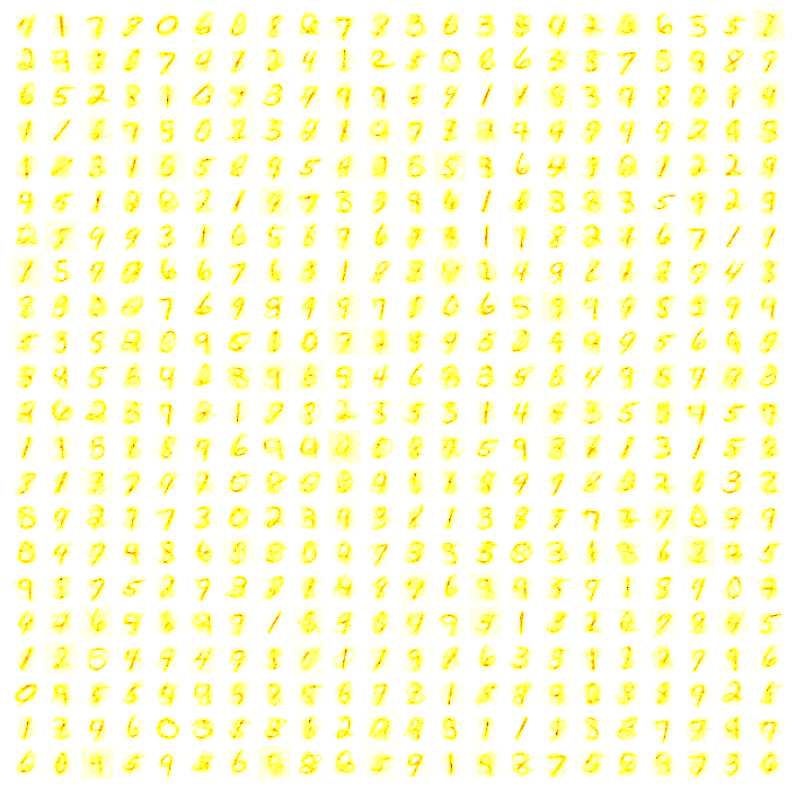

In [13]:
from utils import *
final_weights = get_2d_weights(net['feed_forward'], 28*28, N_outputs)
plot_weights(final_weights, N_outputs)

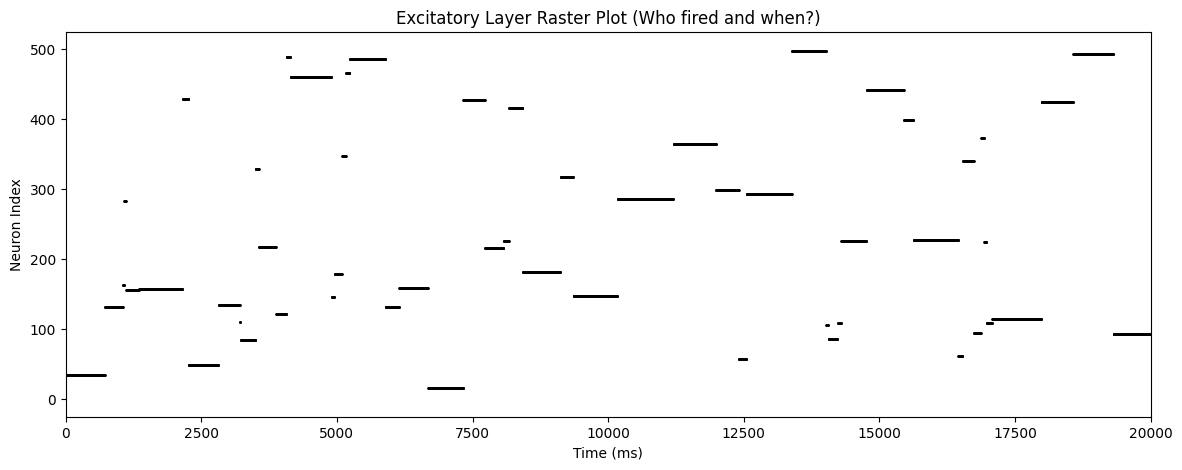

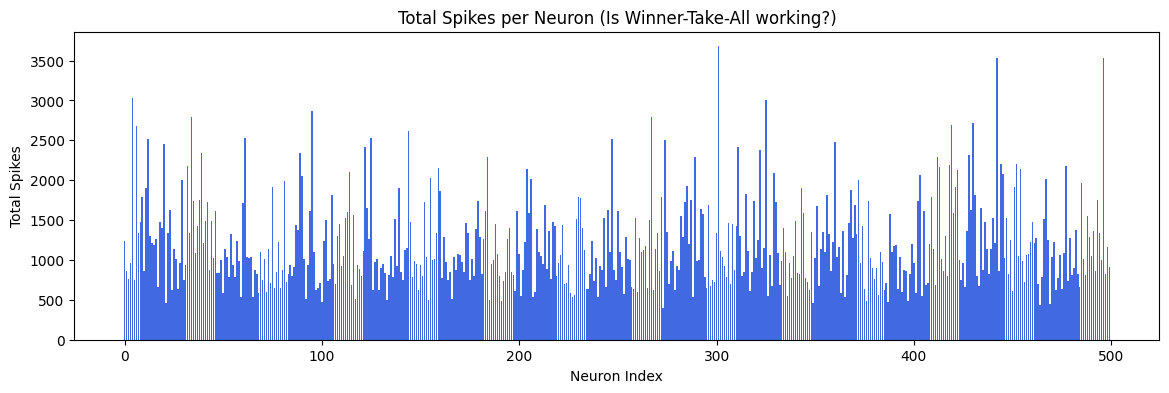

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Raster Plot: Shows EXACTLY when each neuron fired
plt.figure(figsize=(14, 5))
plt.plot(spike_mon.t / ms, spike_mon.i, '.k', markersize=2)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.title('Excitatory Layer Raster Plot (Who fired and when?)')
# Limit the view to the first few images (e.g., first 2000 ms) so it isn't too squished
plt.xlim(0, 20000) 
plt.show()

# 2. Total Spikes per Neuron: Shows who the "winners" were
plt.figure(figsize=(14, 4))
spike_counts = np.array(spike_mon.count)
plt.bar(range(len(spike_counts)), spike_counts, color='royalblue')
plt.xlabel('Neuron Index')
plt.ylabel('Total Spikes')
plt.title('Total Spikes per Neuron (Is Winner-Take-All working?)')
plt.show()

In [12]:
import os
save_path = '../trained_model/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 1. Save the Feedforward weights
trained_weights = np.array(FeedForward.w)
np.save(os.path.join(save_path, 'weights.npy'), trained_weights)

# 2. Save the Adaptation variable 'n'
trained_n = np.array(OutputLayer.n)
np.save(os.path.join(save_path, 'adaptation_n.npy'), trained_n)

print(f"Successfully saved weights and adaptation states to {save_path}")

Successfully saved weights and adaptation states to ../trained_model/


# Testing

In [13]:
input_eqs_test = '''
dv/dt = (-v + I_pixel + bias_in) / tau_m : 1 (unless refractory)
I_pixel : 1
'''
InputLayer = NeuronGroup(N_inputs, input_eqs_test, threshold='v > v_th', 
                         reset='v = v_reset_in', refractory=t_ref, method='exact')


In [17]:
weights_path = '../trained_model/weights.npy'
adaptation_path = '../trained_model/adaptation_n.npy'
labels_path = '../trained_model/neuron_labels.npy'

FeedForward.w = np.load(weights_path)
OutputLayer.n = np.load(adaptation_path) 
net.store('inference_init')

In [19]:
spike_counts = np.zeros((N_outputs, 10))
num_examples = 100

for i in tqdm(range(num_examples)):
    
    net.restore('inference_init') # Reset network
    InputLayer.I_pixel = X_train[i]
    current_label = int(y_train[i])
    net.run(presentation_time)
    spike_counts[:, current_label] += spike_mon.count

neuron_labels = np.argmax(spike_counts, axis=1)
dead_neurons = np.sum(spike_counts, axis=1) == 0
neuron_labels[dead_neurons] = -1  # assign -1 to inactive neurons


  0%|                                                                                                                                     | 0/100 [00:00<?, ?it/s]WARNING    The object 'neurongroup_1' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_240466/1755197508.py', line 8, in <module>
    OutputLayer = NeuronGroup(N_outputs, output_eqs, threshold='v > v_th and t >= clamp_release_time', [brian2.core.base.unused_brian_object]
WARNING    The object 'neurongroup_2' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_240466/3077172114.py', line 5, in

In [20]:
num_test_images = 500
predictions = []
actuals = []

for i in tqdm(range(num_test_images)):
    
    net.restore('inference_init')
    
    true_label = int(y_train[i])
    actuals.append(true_label)
    InputLayer.I_pixel = X_train[i]
    net.run(350 * ms)
    
    class_spikes = np.zeros(10)
    for digit in range(10):
        neurons_in_class = (neuron_labels == digit)
        class_spikes[digit] = np.sum(spike_mon.count[neurons_in_class])
    
    if np.sum(class_spikes) > 0:  
        predicted_label = np.argmax(class_spikes)
    else:
        predicted_label = -1  # Network stayed silent
        
    predictions.append(predicted_label)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [03:10<00:00,  2.63it/s]


In [21]:
predictions = np.array(predictions)
actuals = np.array(actuals)

valid_idx = predictions != -1
correct_predictions = np.sum(predictions[valid_idx] == actuals[valid_idx])
accuracy = (correct_predictions / num_test_images) * 100.0

print(f"\nFinal Accuracy: {accuracy:.2f}% ({correct_predictions} / {num_test_images})")
print(f"Silent Images: {np.sum(predictions == -1)}")


Final Accuracy: 26.60% (133 / 500)
Silent Images: 0


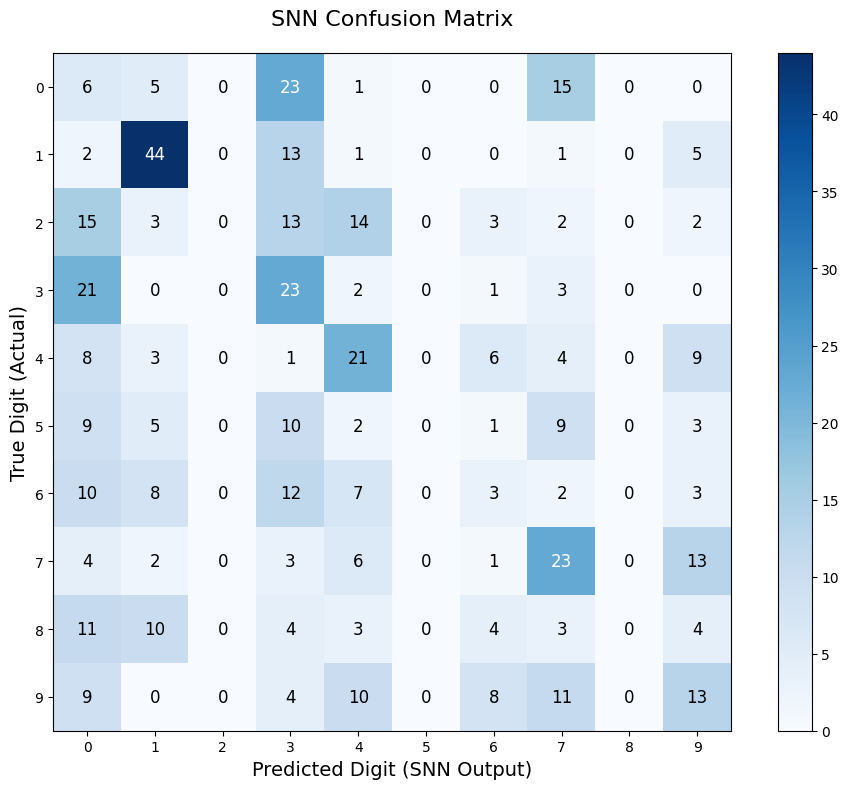

In [23]:
from sklearn.metrics import confusion_matrix
from utils import *
conf_matrix = confusion_matrix(actuals[valid_idx], predictions[valid_idx], labels=np.arange(10))
plot_confusion_matrix(conf_matrix)

In [ ]:
conf_matrix